In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import numpy as np
import h5py
import os
from astropy.cosmology import Planck18 as cosmo

# Load observations
from cmass.survey.tools import sky_to_xyz, xyz_to_sky, rotate_to_z

from scipy.spatial import ConvexHull

# Use the custom style file
plt.style.use('../../style.mcstyle')

Duplicate key in file '../../style.mcstyle', line 16 ('font.family: serif')


In [2]:
imdir = './figures'
if not os.path.exists(imdir):
    os.makedirs(imdir, exist_ok=True)

Files in directory /anvil/scratch/x-mho1/cmass-ili/mtnglike/fastpm_recnoise/L3000-N384/663/ngc_lightcone/: ['hod06631_aug00000.h5', 'hod06632_aug00000.h5', 'hod06633_aug00000.h5', 'hod06634_aug00000.h5', 'hod06635_aug00000.h5']


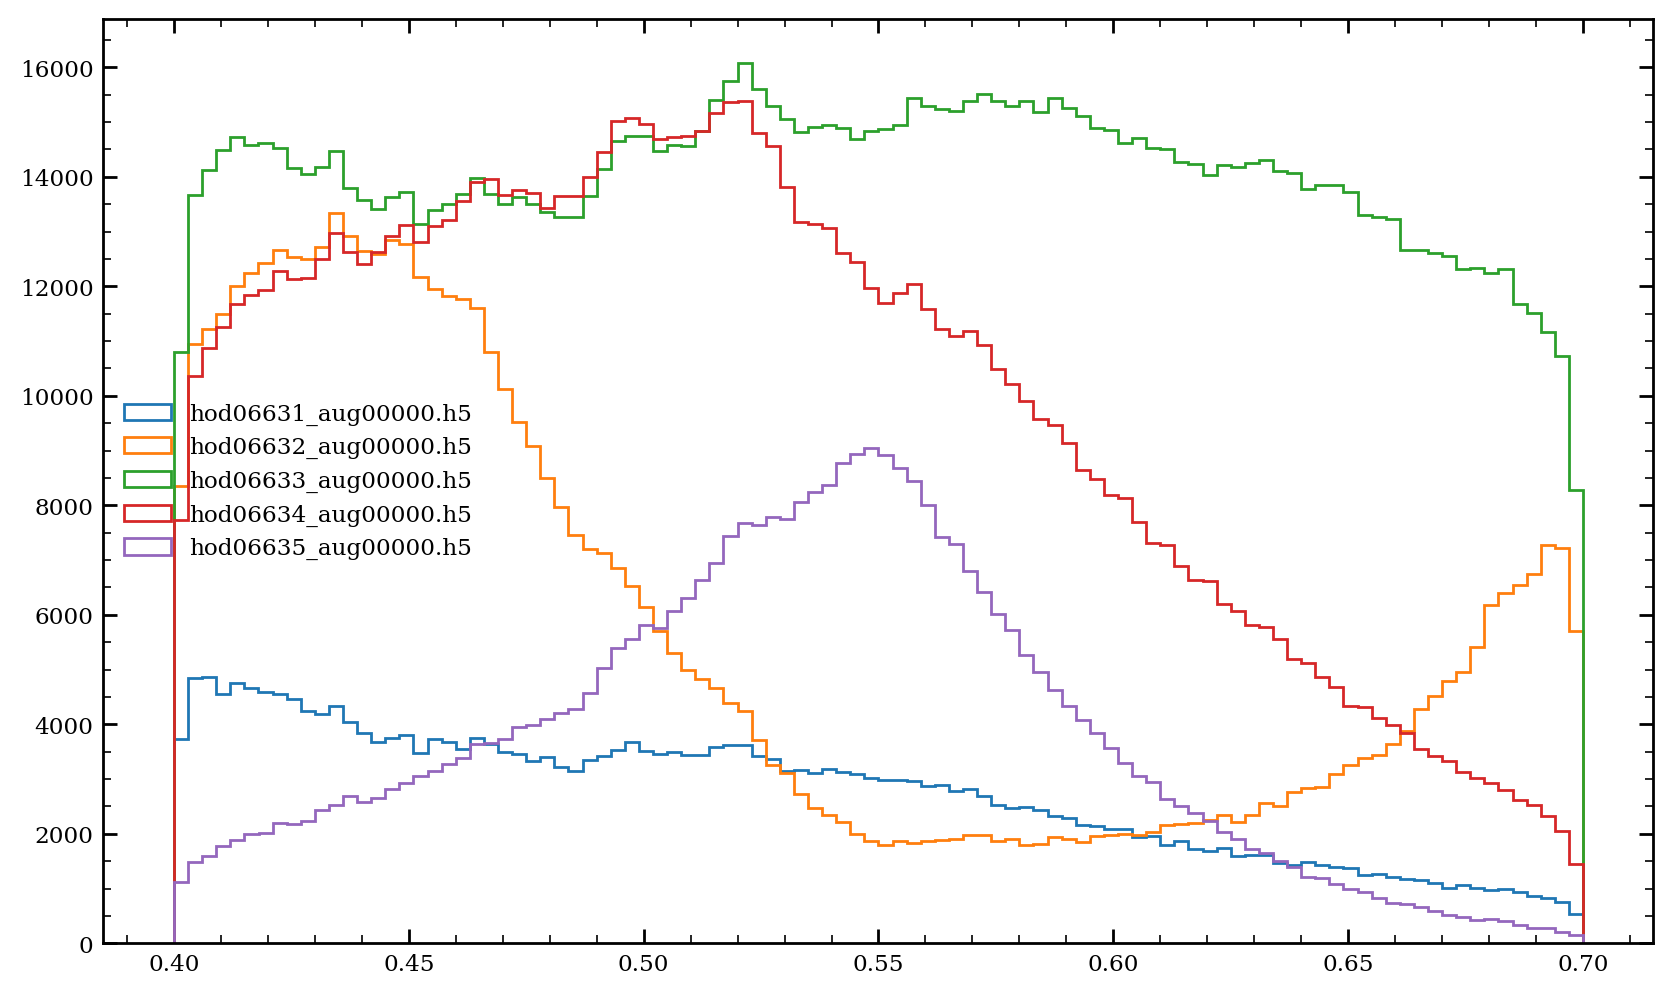

In [2]:
dirname = '/anvil/scratch/x-mho1/cmass-ili/mtnglike/fastpm_recnoise/L3000-N384/663/ngc_lightcone/'

all_f = os.listdir(dirname)
all_f.sort()
print(f"Files in directory {dirname}: {all_f}")

for x in all_f:
    fname = os.path.join(dirname, x)
    with h5py.File(fname, 'r') as f:
        z = f['z'][:]
        plt.hist(z, bins=100, histtype='step', label=x)
plt.legend()

In [4]:
# Load simulations
def load_lightcone(filepath):
    with h5py.File(filepath, 'r') as f:
        ra = f['ra'][...]
        dec = f['dec'][...]
        z = f['z'][...]
        galsnap = f['galsnap'][...]
    rdz = np.array([ra, dec, z]).T
    return rdz, galsnap

dirname = '/anvil/scratch/x-mho1/cmass-ili/mtnglike/fastpm_recnoise/L3000-N384/663/ngc_lightcone/'
fname = os.path.join(dirname, 'hod06634_aug00000.h5')
ncrdz, ncgalsnap = load_lightcone(fname)
ncxyz = sky_to_xyz(ncrdz, cosmo)

def rotate_to_middle(xyz, cosmo):
    # find middle ra, dec, z
    mean_xyz = np.mean(xyz, axis=0)
    med_rdz = xyz_to_sky(mean_xyz, cosmo=cosmo)[0]
    med_xyz = sky_to_xyz(med_rdz, cosmo)

    # rotate to z
    rot, rot_inv = rotate_to_z(med_xyz, cosmo)
    zcxyz = xyz - med_xyz
    zcxyz = rot.apply(zcxyz)
    return zcxyz

ncxyz = rotate_to_middle(ncxyz, cosmo)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


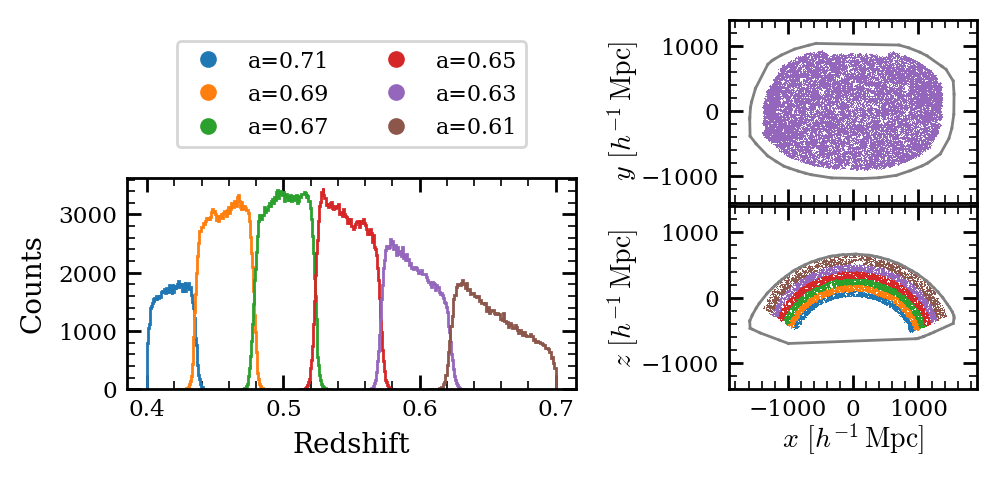

In [130]:
fig = plt.figure(figsize=(7.5, 2.4))
gs = gridspec.GridSpec(2, 2, width_ratios=[0.3, 1], height_ratios=[1., 1.], hspace=0.02, wspace=0.05)

# Large left axis (spans both rows of first column)
ax_left = fig.add_subplot(gs[:, 0])  # ":" means span both rows

# Two right stacked axes
ax_top_right = fig.add_subplot(gs[0, 1])
ax_bottom_right = fig.add_subplot(gs[1, 1])

redshift = ncrdz[:, 2]
all_a = [0.70688, 0.68677, 0.66666, 0.64655, 0.62644, 0.60633]

def plot_convex_hull(xy, ax, **kwargs):
    hull = ConvexHull(xy)
    for simplex in hull.simplices:
        ax.plot(xy[simplex, 0], xy[simplex, 1], **kwargs)


axlim = [1900, 1400, 1000]

for ax in [ax_top_right, ax_bottom_right]:
    ax.set_aspect('equal')

dz = (0.58, 0.6)
ddec = 33, 35

# plot redshift distribution
bins = np.linspace(redshift.min(), redshift.max(), 500)
for i, a in enumerate(all_a):
    m = ncgalsnap == i
    ax_left.hist(redshift[m], bins=100, histtype='step', label=f'a={a:.2f}', lw=1.)
ax_left.set_xlabel('Redshift')
ax_left.set_ylabel('Counts')

ms = 3.
alpha = 1.

# plot face-on
ax = ax_top_right
for i, a in enumerate(all_a):
    m = (ncrdz[:, 2] > dz[0]) & (ncrdz[:, 2] < dz[1]) & (ncgalsnap == i)
    ax.plot(ncxyz[m, 0], ncxyz[m, 1], ',',  rasterized=True, alpha=alpha, ms=ms)
plot_convex_hull(ncxyz[:, :2], ax, c='gray', lw=1, ls='-')
ax.set_xlim(-axlim[0], axlim[0])
ax.set_ylim(-axlim[1], axlim[1])
# ax.set_xlabel(r'$x$ $[h^{-1} \, \mathrm{Mpc}]$', labelpad=0)
ax.set_ylabel(r'$y$ $[h^{-1} \, \mathrm{Mpc}]$', labelpad=0)
ax.set_aspect('equal')

# plot edge-on
ax = ax_bottom_right
for i, a in enumerate(all_a):
    m = (ncrdz[:, 1] > ddec[0]) & (ncrdz[:, 1] < ddec[1]) & (ncgalsnap == i)
    ax.plot(ncxyz[m, 0], ncxyz[m, 2], ',',  rasterized=True, alpha=alpha, ms=ms)
plot_convex_hull(ncxyz[:, [0, 2]], ax, c='gray', lw=1, ls='-')
ax.set_ylim(-axlim[2], axlim[2])
ax.set_xlabel(r'$x$ $[h^{-1} \, \mathrm{Mpc}]$', labelpad=0)
ax.set_ylabel(r'$z$ $[h^{-1} \, \mathrm{Mpc}]$', labelpad=0)
ax.set_aspect('equal')

handles, labels = ax_left.get_legend_handles_labels()
custom_lines = [mpl.lines.Line2D([0], [0], marker='.', lw=0, color=f'C{i}', ms=10, label=f'a={a:.2f}') for i, a in enumerate(all_a)]
custom_labels = [f'a={a:.2f}' for a in all_a]
ax_left.legend(custom_lines, custom_labels, loc='upper center', 
              fontsize=8, ncol=len(labels)//3, bbox_to_anchor=(0.5, 1.7),
              frameon=True, fancybox=True,)

ax_bottom_right.sharex(ax_top_right)
ax_bottom_right.sharey(ax_top_right)

pos0 = ax_left.get_position()
pos1 = ax_top_right.get_position()
pos2 = ax_bottom_right.get_position()
ax_left.set_position([pos0.x0, pos0.y0, pos0.x1, pos1.y1 * 0.5])

fig.align_ylabels()

fig.savefig(os.path.join(imdir, 'lightcone_construction.pdf'),
            dpi=400, bbox_inches='tight')

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


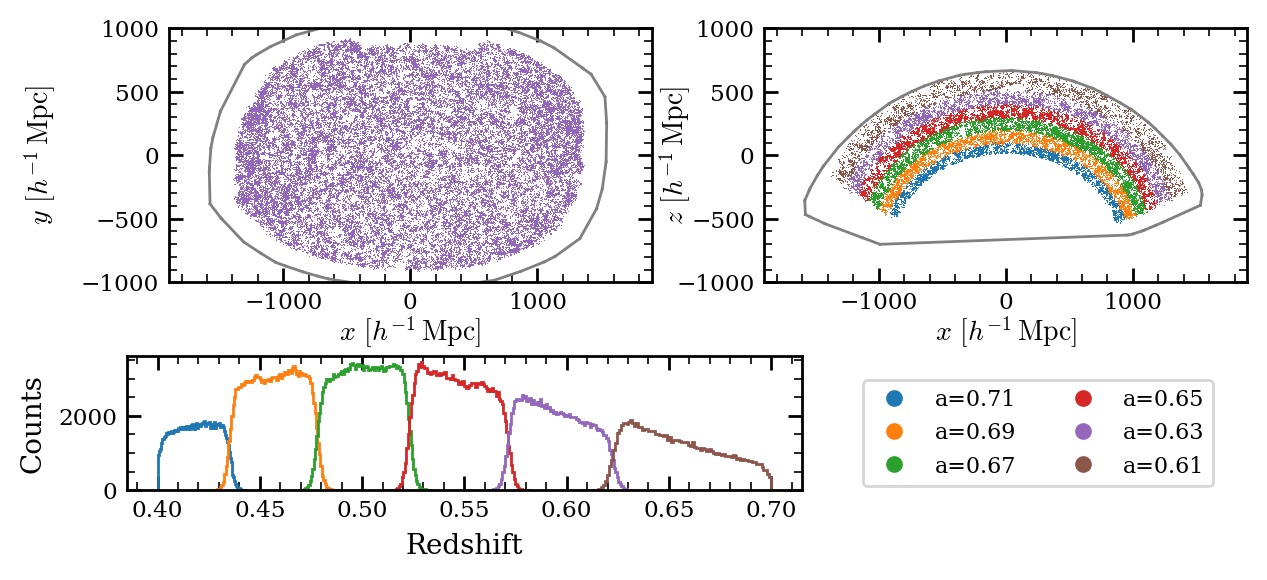

In [33]:
fig = plt.figure(figsize=(7.5, 3))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1., 0.8], hspace=0.02, wspace=0.05)

# Large left axis (spans both rows of first column)
ax_bottom = fig.add_subplot(gs[1, :])  # ":" means span both rows

# Two right stacked axes
ax_top_left = fig.add_subplot(gs[0, 0])
ax_top_right = fig.add_subplot(gs[0, 1])

redshift = ncrdz[:, 2]
all_a = [0.70688, 0.68677, 0.66666, 0.64655, 0.62644, 0.60633]

def plot_convex_hull(xy, ax, **kwargs):
    hull = ConvexHull(xy)
    for simplex in hull.simplices:
        ax.plot(xy[simplex, 0], xy[simplex, 1], **kwargs)


axlim = [1900, 1400, 1000]

for ax in [ax_top_right, ax_top_left]:
    ax.set_aspect('equal')

ax_top_left.sharex(ax_top_right)
ax_top_left.sharey(ax_top_right)

dz = (0.58, 0.6)
ddec = 33, 35

# plot redshift distribution
bins = np.linspace(redshift.min(), redshift.max(), 500)
ax = ax_bottom
for i, a in enumerate(all_a):
    m = ncgalsnap == i
    ax.hist(redshift[m], bins=100, histtype='step', label=f'a={a:.2f}', lw=1.)
ax.set_xlabel('Redshift')
ax.set_ylabel('Counts')

ms = 3.
alpha = 1.

# plot face-on
ax = ax_top_left
for i, a in enumerate(all_a):
    m = (ncrdz[:, 2] > dz[0]) & (ncrdz[:, 2] < dz[1]) & (ncgalsnap == i)
    ax.plot(ncxyz[m, 0], ncxyz[m, 1], ',',  rasterized=True, alpha=alpha, ms=ms)
plot_convex_hull(ncxyz[:, :2], ax, c='gray', lw=1, ls='-')
ax.set_xlim(-axlim[0], axlim[0])
ax.set_ylim(-axlim[1], axlim[1])
ax.set_xlabel(r'$x$ $[h^{-1} \, \mathrm{Mpc}]$', labelpad=0)
ax.set_ylabel(r'$y$ $[h^{-1} \, \mathrm{Mpc}]$', labelpad=0)
ax.set_aspect('equal')

# plot edge-on
ax = ax_top_right
for i, a in enumerate(all_a):
    m = (ncrdz[:, 1] > ddec[0]) & (ncrdz[:, 1] < ddec[1]) & (ncgalsnap == i)
    ax.plot(ncxyz[m, 0], ncxyz[m, 2], ',',  rasterized=True, alpha=alpha, ms=ms)
plot_convex_hull(ncxyz[:, [0, 2]], ax, c='gray', lw=1, ls='-')
ax.set_ylim(-axlim[2], axlim[2])
ax.set_xlabel(r'$x$ $[h^{-1} \, \mathrm{Mpc}]$', labelpad=0)
ax.set_ylabel(r'$z$ $[h^{-1} \, \mathrm{Mpc}]$', labelpad=-6)
ax.set_aspect('equal')

custom_lines = [mpl.lines.Line2D([0], [0], marker='.', lw=0, color=f'C{i}', ms=10, label=f'a={a:.2f}') for i, a in enumerate(all_a)]
custom_labels = [f'a={a:.2f}' for a in all_a]
ax_bottom.legend(custom_lines, custom_labels, loc='upper center', 
              fontsize=8, ncol=len(labels)//3, bbox_to_anchor=(1.35, 0.9),
              frameon=True, fancybox=True,)

pos0 = ax_bottom.get_position()
pos1 = ax_top_left.get_position()
pos2 = ax_top_right.get_position()
ax_bottom.set_position([pos0.x0, pos0.y0, pos0.x1 * 0.5, pos0.y1 * 0.5])

fig.align_labels()

fig.savefig(os.path.join(imdir, 'lightcone_construction.pdf'),
            dpi=400, bbox_inches='tight')